# gparis vf calibration: default vs. gravity-adjusted

The all-metrics notebook (`simulation_calibration.ipynb`) tries to show every tracked metric improving at once, which makes any single metric's story hard to see. This notebook isolates **visitation frequency (`vf`)** for the gparis scenario and compares the empirical distribution of *visits per user* across three trajectories:

- **Real** -- observed GreaterParis mobility (`data/gparis/gparis_visitation_df.parquet`)
- **Default synthetic** -- v4 series baseline, `gravity_deterrence_exponent=-2.5` (single seed 42, regenerated for this notebook: no cached trajectory survived from the original `gparis_final_run{1,2,3}` batch, only their report JSONs)
- **Adjusted synthetic** -- v4 round 3's kept lever, `gravity_deterrence_exponent=-3.2` (single seed 42, `data/ablation_logs/gparis_r3_gravity_trajectories_20260917T100427.parquet`)

Both synthetic runs share every other config value (schedule_guidance, car_speed_kmh=60, rho=0.6, gamma=0.21, location_count_mu=0.6/sigma=0.6/max_locations=5) -- `gravity_deterrence_exponent` is the only lever that differs, isolating its effect on `vf`.

`vf` itself is a Wasserstein-1 distance between the two sides' per-user visit-count distributions (`citybehavex/reports/comparison.py`, `generate_comparison_report`), where a "visit" is a stay episode (consecutive same-location rows collapsed to one), not a raw 15-minute slot. Report values: default W1 = 0.9206, adjusted W1 = 0.8353 -- a real but modest tightening; the plot below shows *where* in the distribution that improvement comes from.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from citybehavex.reports.comparison import (
    _DATETIME_CANDIDATES,
    _LAT_CANDIDATES,
    _LNG_CANDIDATES,
    _UID_CANDIDATES,
    _collapse_to_stays,
    _traj_dataframe,
    detect_column,
    load_trajectory,
)

REPO_ROOT = Path.cwd().resolve().parents[1]

In [2]:
REAL_PATH = REPO_ROOT / "data/gparis/gparis_visitation_df.parquet"
DEFAULT_SYNTH_PATH = REPO_ROOT / "data/ablation_logs/gparis_v4_default_vf_trajectories_20260917T142427.parquet"
ADJUSTED_SYNTH_PATH = REPO_ROOT / "data/ablation_logs/gparis_r3_gravity_trajectories_20260917T100427.parquet"


def visit_counts_per_user(path: Path) -> np.ndarray:
    """Load a trajectory parquet, collapse slot-by-slot rows into stay
    episodes the same way generate_comparison_report does, and return the
    per-user visit-count array (one count per distinct user)."""
    df = pl.read_parquet(path)
    datetime_col = detect_column(df, _DATETIME_CANDIDATES)
    lat_col = detect_column(df, _LAT_CANDIDATES)
    lng_col = detect_column(df, _LNG_CANDIDATES)
    uid_col = detect_column(df, _UID_CANDIDATES)
    stays = _collapse_to_stays(
        df, uid_col=uid_col, lat_col=lat_col, lng_col=lng_col, datetime_col=datetime_col
    )
    return stays.group_by(uid_col).len()["len"].to_numpy()


real_visits = visit_counts_per_user(REAL_PATH)
default_visits = visit_counts_per_user(DEFAULT_SYNTH_PATH)
adjusted_visits = visit_counts_per_user(ADJUSTED_SYNTH_PATH)

print(f"real:     n_users={len(real_visits)}, mean={real_visits.mean():.2f}, median={np.median(real_visits):.1f}")
print(f"default:  n_users={len(default_visits)}, mean={default_visits.mean():.2f}, median={np.median(default_visits):.1f}")
print(f"adjusted: n_users={len(adjusted_visits)}, mean={adjusted_visits.mean():.2f}, median={np.median(adjusted_visits):.1f}")

real:     n_users=504, mean=21.49, median=21.0
default:  n_users=504, mean=22.03, median=21.5
adjusted: n_users=504, mean=21.89, median=21.0


## Empirical CDF of visits per user

A closer synthetic curve to the real (black) curve means a better match on this metric. The adjusted (orange) config should hug the real curve more tightly than the default (blue) config, consistent with the round-3 vf W1 improvement (0.9206 -> 0.8353).

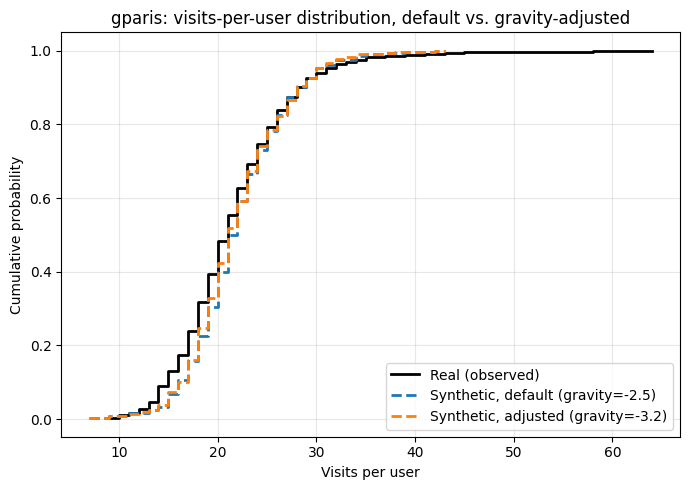

In [3]:
def ecdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


fig, ax = plt.subplots(figsize=(7, 5))

for values, label, color, style in [
    (real_visits, "Real (observed)", "black", "-"),
    (default_visits, "Synthetic, default (gravity=-2.5)", "tab:blue", "--"),
    (adjusted_visits, "Synthetic, adjusted (gravity=-3.2)", "tab:orange", "--"),
]:
    x, y = ecdf(values)
    ax.step(x, y, where="post", label=label, color=color, linestyle=style, linewidth=2)

ax.set_xlabel("Visits per user")
ax.set_ylabel("Cumulative probability")
ax.set_title("gparis: visits-per-user distribution, default vs. gravity-adjusted")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("outputs/gparis_vf_calibration_cdf.pdf")
fig.savefig("outputs/gparis_vf_calibration_cdf.png", dpi=150)
plt.show()